In [42]:
import yfinance

Stock_Ticker = "F"

Start_Date = "2019-01-01"

End_Date = "2024-01-01"

dataframe = yfinance.download(tickers = Stock_Ticker,
                     start = Start_Date,
                        end = End_Date)
dataframe

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,F,F,F,F,F
Date,,,,,
2019-01-02,5.936495,6.026670,5.620884,5.658457,47494400
2019-01-03,5.846320,6.004125,5.846320,5.989096,39172400
2019-01-04,6.071757,6.101815,5.898922,5.944009,43039800
2019-01-07,6.229562,6.289678,6.034183,6.094300,40729400
2019-01-08,6.289680,6.417428,6.274652,6.327253,45644000
...,...,...,...,...,...
2023-12-22,11.542161,11.644965,11.476739,11.514123,43718600
2023-12-26,11.635619,11.682349,11.560852,11.579544,26293700


In [43]:
import numpy

dataframe["Volume Decrease/Increase"] = numpy.where(dataframe["Volume"].shift(-1) > dataframe["Volume"], 
                                                    1, 
                                                    0)

dataframe["Buy or Sell"] = numpy.where(dataframe["Close"].shift(-1) > dataframe["Close"],
                                      1,
                                      0)

dataframe["Returns"] = dataframe["Close"].pct_change()

In [44]:
dataframe

Price,Close,High,Low,Open,Volume,Volume Decrease/Increase,Buy or Sell,Returns
Ticker,F,F,F,F,F,,,
Date,,,,,,,,
2019-01-02,5.936495,6.026670,5.620884,5.658457,47494400,0,0,NaN
2019-01-03,5.846320,6.004125,5.846320,5.989096,39172400,1,1,-0.015190
2019-01-04,6.071757,6.101815,5.898922,5.944009,43039800,0,1,0.038560
2019-01-07,6.229562,6.289678,6.034183,6.094300,40729400,1,1,0.025990
2019-01-08,6.289680,6.417428,6.274652,6.327253,45644000,1,1,0.009651
...,...,...,...,...,...,...,...,...
2023-12-22,11.542161,11.644965,11.476739,11.514123,43718600,0,1,0.000810
2023-12-26,11.635619,11.682349,11.560852,11.579544,26293700,1,0,0.008097


In [45]:
dataframe = dataframe.dropna()

dataframe

Price,Close,High,Low,Open,Volume,Volume Decrease/Increase,Buy or Sell,Returns
Ticker,F,F,F,F,F,,,
Date,,,,,,,,
2019-01-03,5.846320,6.004125,5.846320,5.989096,39172400,1,1,-0.015190
2019-01-04,6.071757,6.101815,5.898922,5.944009,43039800,0,1,0.038560
2019-01-07,6.229562,6.289678,6.034183,6.094300,40729400,1,1,0.025990
2019-01-08,6.289680,6.417428,6.274652,6.327253,45644000,1,1,0.009651
2019-01-09,6.552690,6.590262,6.282165,6.349796,48404900,0,0,0.041816
...,...,...,...,...,...,...,...,...
2023-12-22,11.542161,11.644965,11.476739,11.514123,43718600,0,1,0.000810
2023-12-26,11.635619,11.682349,11.560852,11.579544,26293700,1,0,0.008097


In [46]:
X = dataframe["Open"].values

X

array([[ 5.98909629],
       [ 5.94400942],
       [ 6.09429968],
       ...,
       [11.6169285 ],
       [11.57019846],
       [11.54216062]])

In [47]:
X.shape

(1257, 1)

In [48]:
y = dataframe["Close"].values

y

array([[ 5.84632015],
       [ 6.07175684],
       [ 6.22956181],
       ...,
       [11.57954502],
       [11.53281498],
       [11.39262581]])

In [49]:
y.shape

(1257, 1)

In [50]:
from sklearn.model_selection import train_test_split



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/5)

In [51]:
X_train.shape

(1005, 1)

In [52]:
y_train.shape

(1005, 1)

In [53]:
import matplotlib.pyplot as pyplot

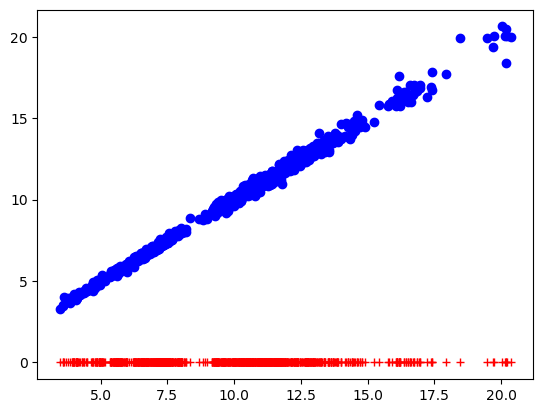

In [54]:
pyplot.plot(X_train, y_train, "bo")

pyplot.plot(X_train, numpy.zeros_like(X_train), "r+")

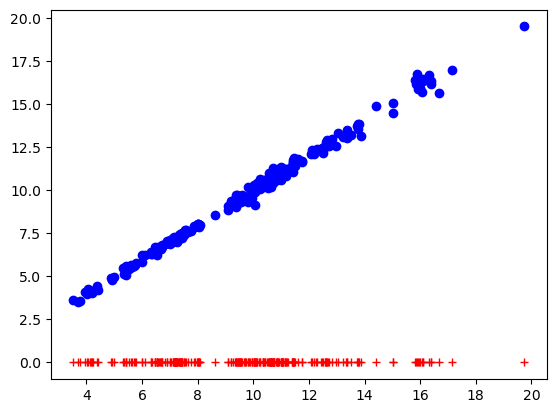

In [55]:
pyplot.plot(X_test, y_test, "bo")

pyplot.plot(X_test, numpy.zeros_like(X_test), "r+")

In [56]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train.reshape(-1, 1), y_train)

prediction = model.predict(X_test.reshape(-1, 1))

prediction

array([[11.42080461],
       [ 7.98660498],
       [ 7.23910147],
       [11.17378058],
       [19.7165451 ],
       [12.41146992],
       [ 9.68671163],
       [10.70865415],
       [ 7.15770279],
       [ 9.82315509],
       [15.92354475],
       [ 6.09809383],
       [ 7.32565284],
       [ 9.71633254],
       [11.25649713],
       [12.58079984],
       [10.42758873],
       [ 7.199759  ],
       [11.4042341 ],
       [ 9.45559111],
       [ 7.18156179],
       [10.03645762],
       [10.9752705 ],
       [10.90675292],
       [ 5.00988914],
       [ 4.20466256],
       [ 3.70851219],
       [10.02364528],
       [ 7.26167458],
       [10.64563528],
       [ 9.49963967],
       [ 9.60440451],
       [ 9.19399928],
       [10.84981713],
       [10.88073742],
       [ 9.26376591],
       [10.19912823],
       [ 6.5390073 ],
       [ 7.16828624],
       [ 7.90039908],
       [10.09875608],
       [ 7.18836926],
       [12.17559375],
       [ 7.18969666],
       [10.3577955 ],
       [ 9

In [57]:
X_train = X_train.flatten()

In [58]:
y_train = y_train.flatten()

In [59]:
model_1d_polynomial = numpy.poly1d(numpy.polyfit(X_train, y_train, 1))

model_1d_prediction = model_1d_polynomial(X_test)

model_1d_prediction[:5]

array([[11.42080461],
       [ 7.98660498],
       [ 7.23910147],
       [11.17378058],
       [19.7165451 ]])

In [60]:
model_2d_polynomial = numpy.poly1d(numpy.polyfit(X_train, y_train, 2))

model_2d_prediction = model_2d_polynomial(X_test)

model_2d_prediction

array([[11.42874618],
       [ 7.9909781 ],
       [ 7.23999204],
       [11.18214698],
       [19.64887362],
       [12.41664634],
       [ 9.69540331],
       [10.71753376],
       [ 7.15815573],
       [ 9.83197645],
       [15.90522924],
       [ 6.09180331],
       [ 7.32699617],
       [ 9.72505511],
       [11.26473304],
       [12.5853336 ],
       [10.4365969 ],
       [ 7.20043949],
       [11.41220747],
       [ 9.4639896 ],
       [ 7.1821442 ],
       [10.04541713],
       [10.98390175],
       [10.91545974],
       [ 4.99464997],
       [ 4.18148199],
       [ 3.6798795 ],
       [10.03259871],
       [ 7.26268448],
       [10.65455561],
       [ 9.50810117],
       [ 9.61300238],
       [ 9.20195435],
       [10.85858057],
       [10.8894708 ],
       [ 9.27185082],
       [10.20814014],
       [ 6.53575894],
       [ 7.16879673],
       [ 7.90441992],
       [10.10774107],
       [ 7.18898842],
       [12.18158266],
       [ 7.19032299],
       [10.3668144 ],
       [ 9

In [61]:
from sklearn.metrics import mean_squared_error

numpy.sqrt(mean_squared_error(y_test, model_1d_prediction))

0.21748195037427126

In [62]:
numpy.sqrt(mean_squared_error(y_test, model_2d_prediction))

0.21723769121153594

In [63]:
model_9d_polynomial = numpy.poly1d(numpy.polyfit(X_train, y_train, 9))

model_9d_prediction = model_9d_polynomial(X_test)

model_9d_prediction[:5]

array([[11.41304483],
       [ 8.0065274 ],
       [ 7.23920094],
       [11.17050489],
       [20.0371123 ]])

In [64]:
numpy.sqrt(mean_squared_error(y_test, model_9d_prediction))

0.22066166726369318

In [65]:
errors = []

for coefficient in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]:
    
    model = numpy.poly1d(numpy.polyfit(X_train, y_train, coefficient))
    
    training_error = numpy.sqrt(mean_squared_error(y_train, model(X_train)))
    
    testing_error = numpy.sqrt(mean_squared_error(y_test, model(X_test)))

    errors.append((coefficient, training_error, testing_error))

columns = ["Coefficient", "Training Error", "Testing Error"]

import pandas

dataframe = pandas.DataFrame.from_records(errors, columns = columns, index = "Coefficient")

dataframe

C:\Users\David Moon\AppData\Local\Temp\ipykernel_44524\175519512.py:5: RankWarning: Polyfit may be poorly conditioned
  model = numpy.poly1d(numpy.polyfit(X_train, y_train, coefficient))
C:\Users\David Moon\AppData\Local\Temp\ipykernel_44524\175519512.py:5: RankWarning: Polyfit may be poorly conditioned
  model = numpy.poly1d(numpy.polyfit(X_train, y_train, coefficient))
C:\Users\David Moon\AppData\Local\Temp\ipykernel_44524\175519512.py:5: RankWarning: Polyfit may be poorly conditioned
  model = numpy.poly1d(numpy.polyfit(X_train, y_train, coefficient))
C:\Users\David Moon\AppData\Local\Temp\ipykernel_44524\175519512.py:5: RankWarning: Polyfit may be poorly conditioned
  model = numpy.poly1d(numpy.polyfit(X_train, y_train, coefficient))
C:\Users\David Moon\AppData\Local\Temp\ipykernel_44524\175519512.py:5: RankWarning: Polyfit may be poorly conditioned
  model = numpy.poly1d(numpy.polyfit(X_train, y_train, coefficient))


,Training Error,Testing Error
Coefficient,,
1,0.211972,0.217482
2,0.211639,0.217238
3,0.211639,0.217252
4,0.211573,0.217046
5,0.211188,0.217101
6,0.210939,0.217469
7,0.210278,0.219216
8,0.208753,0.221857
9,0.208344,0.220662


<Axes: xlabel='Coefficient'>

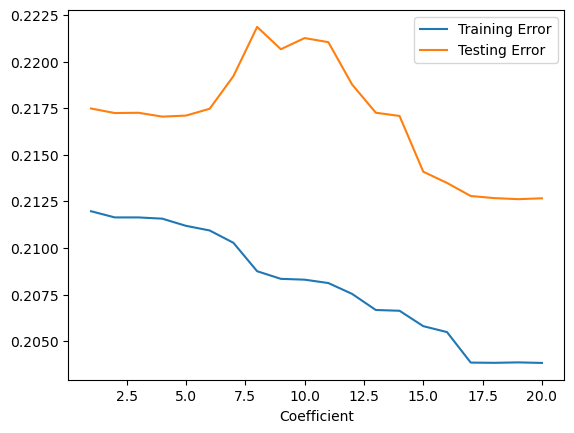

In [66]:
dataframe.plot()